# Longitude-Based Area Equalization of the Azimuthal Equidistant Projection

# Longitude-Based Area Equalization

Given a map projection $X$, an equal-area version of the projection can be constructed by appropriately compressing the longitude coordinate while preserving the central meridian and all parallels.

More precisely, let a transformation on the sphere be defined that preserves latitude while modifying longitude according to a suitable function. The original projection $X$ is then applied to the transformed coordinates. The longitude transformation is chosen so that the resulting projection satisfies the equal-area condition.

In other words, the problem is to find a longitude remapping

$\lambda \mapsto \lambda'(\phi,\lambda)$

that leaves latitude unchanged,

$\phi' = \phi,$

and, after applying projection $X$ to $(\lambda',\phi)$, produces a final equal-area map projection.

This procedure may be viewed as a general framework for constructing equal-area variants of existing projections through longitude adjustment alone, while preserving the original structure of parallels and the central meridian.
 

# Longitude-Based Area Equalization of the Azimuthal Equidistant Projection

An equal-area projection can be obtained from an Azimuthal Equidistant Projection by compressing longitude while preserving its meridional structure. This construction is applicable to equatorial, polar, and oblique aspects of the Azimuthal Equidistant Projection.



In [3]:
def aeqd_forward(lamp, phi):
    cosc = np.cos(phi) * np.cos(lamp)
    cosc = np.clip(cosc, -1.0, 1.0)

    c = np.arccos(cosc)

    sinc = np.sin(c)

    k = np.ones_like(c)
    m = np.abs(sinc) > 1e-12
    k[m] = c[m] / sinc[m]

    x = k * np.cos(phi) * np.sin(lamp)
    y = k * np.sin(phi)

    return x, y


def F_of_lamp(lamp, phi):
    """
    lambda = integral_0^lambda' c/sin(c) du
    because d lambda'/d lambda = sin(c)/c.
    """
    sign = np.sign(lamp)
    lamp = abs(lamp)

    u = np.linspace(0, lamp, 800)

    cosc = np.cos(phi) * np.cos(u)
    cosc = np.clip(cosc, -1.0, 1.0)
    c = np.arccos(cosc)
    sinc = np.sin(c)

    integrand = np.ones_like(u)
    m = np.abs(sinc) > 1e-12
    integrand[m] = c[m] / sinc[m]

    return sign * np.trapz(integrand, u)


def solve_lamp(lam, phi):
    sign = np.sign(lam)
    target = abs(lam)

    if target == 0:
        return 0.0

    lo, hi = 0.0, np.pi - 1e-8

    if F_of_lamp(hi, phi) < target:
        return np.nan

    for _ in range(70):
        mid = 0.5 * (lo + hi)

        if F_of_lamp(mid, phi) < target:
            lo = mid
        else:
            hi = mid

    return sign * 0.5 * (lo + hi)


def project_point(lon_deg, lat_deg, lon0_deg=0):
    lam = np.deg2rad(lon_deg - lon0_deg)
    phi = np.deg2rad(lat_deg)

    lam = wrap_pi_keep_endpoint(lam)

    lamp = solve_lamp(lam, phi)

    return aeqd_forward(np.array([lamp]), np.array([phi]))

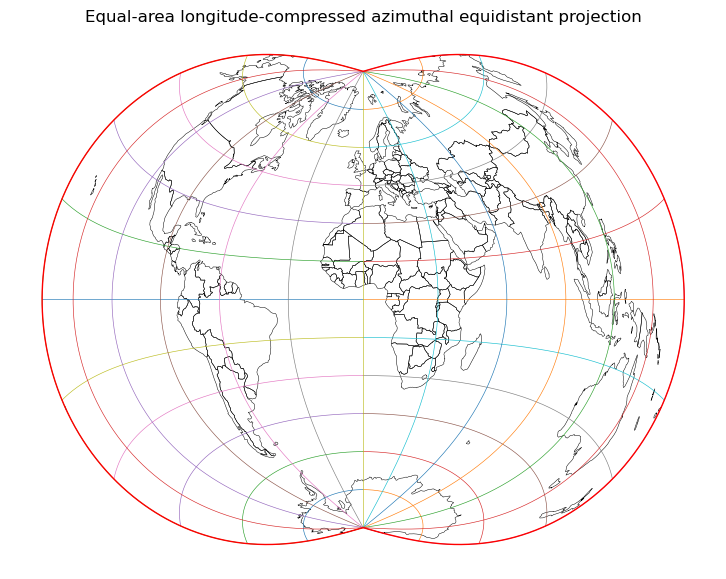

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import geopandas as gpd
from shapely.geometry import Polygon, MultiPolygon

# -----------------------------
# helpers
# -----------------------------

def wrap_pi_keep_endpoint(lam):
    out = (lam + np.pi) % (2*np.pi) - np.pi
    if np.isscalar(lam):
        if np.isclose(out, -np.pi) and lam > 0:
            out = np.pi
    else:
        mask = np.isclose(out, -np.pi) & (lam > 0)
        out[mask] = np.pi
    return out


# -----------------------------
# Azimuthal equidistant, center at equator
# -----------------------------

def aeqd_forward(lamp, phi):
    cosc = np.cos(phi) * np.cos(lamp)
    cosc = np.clip(cosc, -1.0, 1.0)

    c = np.arccos(cosc)
    sinc = np.sin(c)

    k = np.ones_like(c)
    m = np.abs(sinc) > 1e-12
    k[m] = c[m] / sinc[m]

    x = k * np.cos(phi) * np.sin(lamp)
    y = k * np.sin(phi)

    return x, y


def F_of_lamp(lamp, phi):
    sign = np.sign(lamp)
    L = abs(lamp)

    if L == 0:
        return 0.0

    u = np.linspace(0, L, 700)

    cosc = np.cos(phi) * np.cos(u)
    cosc = np.clip(cosc, -1.0, 1.0)

    c = np.arccos(cosc)
    sinc = np.sin(c)

    integrand = np.ones_like(u)
    m = np.abs(sinc) > 1e-12
    integrand[m] = c[m] / sinc[m]

    return sign * np.trapz(integrand, u)


def solve_lamp(lam, phi):
    sign = np.sign(lam)
    target = abs(lam)

    if target == 0:
        return 0.0

    lo, hi = 0.0, np.pi - 1e-8

    if F_of_lamp(hi, phi) < target:
        return np.nan

    for _ in range(70):
        mid = 0.5 * (lo + hi)

        if F_of_lamp(mid, phi) < target:
            lo = mid
        else:
            hi = mid

    return sign * 0.5 * (lo + hi)


def project_point(lon_deg, lat_deg, lon0_deg=0):
    lam = np.deg2rad(lon_deg - lon0_deg)
    phi = np.deg2rad(lat_deg)

    lam = wrap_pi_keep_endpoint(lam)
    lamp = solve_lamp(lam, phi)

    if not np.isfinite(lamp):
        return np.nan, np.nan

    x, y = aeqd_forward(np.array([lamp]), np.array([phi]))
    return x[0], y[0]


def project_array(lon, lat, lon0_deg=0):
    lon = np.asarray(lon)
    lat = np.asarray(lat)

    x = np.empty_like(lon, dtype=float)
    y = np.empty_like(lat, dtype=float)

    for i in range(len(lon)):
        x[i], y[i] = project_point(lon[i], lat[i], lon0_deg)

    return x, y


# -----------------------------
# geometry plotting
# -----------------------------

def densify_coords(coords, step=0.5):
    coords = list(coords)
    out = []

    for (lon1, lat1), (lon2, lat2) in zip(coords[:-1], coords[1:]):
        dlon = lon2 - lon1

        if abs(dlon) > 180:
            out.append((np.nan, np.nan))
            continue

        dlat = lat2 - lat1
        n = max(1, int(max(abs(dlon), abs(dlat)) / step))

        for j in range(n):
            t = j / n
            out.append((lon1 + t*dlon, lat1 + t*dlat))

    out.append(coords[-1])
    return out


def plot_polyline_with_nan(ax, xy, **kwargs):
    isnan = np.isnan(xy[:,0]) | np.isnan(xy[:,1])
    cuts = np.where(isnan)[0]

    start = 0
    for c in list(cuts) + [len(xy)]:
        seg = xy[start:c]
        if len(seg) >= 2:
            ax.plot(seg[:,0], seg[:,1], **kwargs)
        start = c + 1


def project_ring(coords):
    coords = densify_coords(coords)

    lon = np.array([p[0] for p in coords])
    lat = np.array([p[1] for p in coords])

    x, y = project_array(lon, lat)

    return np.column_stack([x, y])


def plot_geom(ax, geom):
    if geom.is_empty:
        return

    if isinstance(geom, Polygon):
        xy = project_ring(geom.exterior.coords)
        plot_polyline_with_nan(ax, xy, color="black", linewidth=0.35)

    elif isinstance(geom, MultiPolygon):
        for g in geom.geoms:
            plot_geom(ax, g)


# -----------------------------
# plot
# -----------------------------

url = "https://naturalearth.s3.amazonaws.com/110m_cultural/ne_110m_admin_0_countries.zip"
world = gpd.read_file(url)

fig, ax = plt.subplots(figsize=(12, 7))

for geom in world.geometry:
    plot_geom(ax, geom)

# graticule: parallels split to avoid seam connection
for lat in range(-75, 76, 15):
    for lo, hi in [(-180, 0), (0, 180)]:
        lons = np.linspace(lo, hi, 361)
        lats = np.full_like(lons, lat)
        x, y = project_array(lons, lats)
        ax.plot(x, y, linewidth=0.45)

# meridians
for lon in range(-180, 181, 30):
    lats = np.linspace(-89.9, 89.9, 721)
    lons = np.full_like(lats, lon)
    x, y = project_array(lons, lats)
    ax.plot(x, y, linewidth=0.45)

# map edge
for lon in [-180, 180]:
    lats = np.linspace(-89.9, 89.9, 721)
    lons = np.full_like(lats, lon)
    x, y = project_array(lons, lats)
    ax.plot(x, y, color="red", linewidth=1.0)

ax.set_aspect("equal", adjustable="box")
ax.autoscale()
ax.set_axis_off()
ax.set_title("Equal-area longitude-compressed azimuthal equidistant projection")

plt.show()

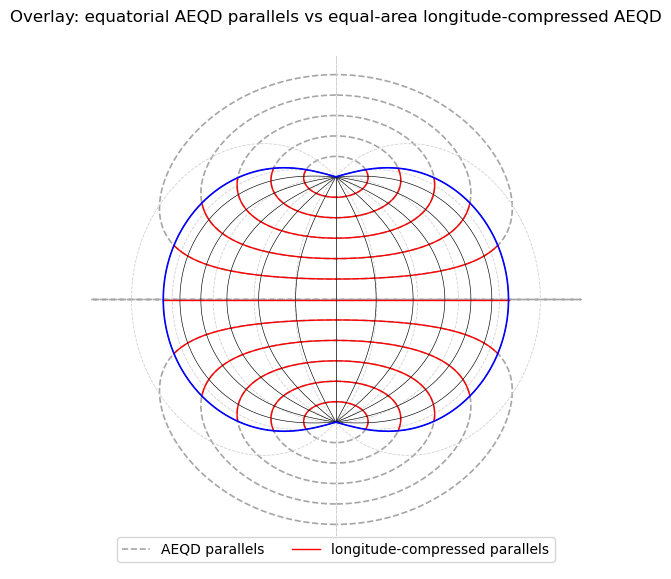

In [6]:
# -----------------------------
# overlay: AEQD parallels vs compressed parallels
# -----------------------------

fig, ax = plt.subplots(figsize=(12, 7))

# 1) original equatorial AEQD graticule: gray dashed
for lat in range(-75, 76, 15):
    lons = np.linspace(-180, 180, 1201)
    phis = np.deg2rad(np.full_like(lons, lat))
    lamps = np.deg2rad(lons)
    x, y = aeqd_forward(lamps, phis)
    ax.plot(x, y, color="0.65", linewidth=1.2, linestyle="--",
            label="AEQD parallels" if lat == -75 else None)

for lon in range(-180, 181, 30):
    lats = np.linspace(-89.9, 89.9, 721)
    phis = np.deg2rad(lats)
    lamps = np.deg2rad(np.full_like(lats, lon))
    x, y = aeqd_forward(lamps, phis)
    ax.plot(x, y, color="0.82", linewidth=0.6, linestyle="--")

# 2) compressed equal-area projection: red/black solid
for lat in range(-75, 76, 15):
    for lo, hi in [(-180, 0), (0, 180)]:
        lons = np.linspace(lo, hi, 721)
        lats = np.full_like(lons, lat)
        x, y = project_array(lons, lats)
        ax.plot(x, y, color="red", linewidth=1.0,
                label="longitude-compressed parallels" if lat == -75 and lo == -180 else None)

for lon in range(-180, 181, 30):
    lats = np.linspace(-89.9, 89.9, 721)
    lons = np.full_like(lats, lon)
    x, y = project_array(lons, lats)
    ax.plot(x, y, color="black", linewidth=0.45)

# map edge of compressed projection
for lon in [-180, 180]:
    lats = np.linspace(-89.9, 89.9, 721)
    lons = np.full_like(lats, lon)
    x, y = project_array(lons, lats)
    ax.plot(x, y, color="blue", linewidth=1.2)

ax.set_aspect("equal", adjustable="box")
ax.autoscale()
ax.set_axis_off()
ax.legend(loc="lower center", ncol=2)
ax.set_title("Overlay: equatorial AEQD parallels vs equal-area longitude-compressed AEQD")

plt.show()

We now implement the transformation function for the generalized aspect, extending the Longitude-Based Area Equalization method from the equatorial and polar cases to an arbitrary projection center.

In [7]:
# -----------------------------
# General AEQD, arbitrary center latitude
# -----------------------------

def aeqd_forward_general(lamp, phi, phi0):
    cosc = np.sin(phi0)*np.sin(phi) + np.cos(phi0)*np.cos(phi)*np.cos(lamp)
    cosc = np.clip(cosc, -1.0, 1.0)

    c = np.arccos(cosc)
    sinc = np.sin(c)

    k = np.ones_like(c)
    m = np.abs(sinc) > 1e-12
    k[m] = c[m] / sinc[m]

    x = k * np.cos(phi) * np.sin(lamp)
    y = k * (np.cos(phi0)*np.sin(phi)
             - np.sin(phi0)*np.cos(phi)*np.cos(lamp))

    return x, y


def F_of_lamp_general(lamp, phi, phi0):
    sign = np.sign(lamp)
    L = abs(lamp)

    if L == 0:
        return 0.0

    u = np.linspace(0, L, 700)

    cosc = np.sin(phi0)*np.sin(phi) + np.cos(phi0)*np.cos(phi)*np.cos(u)
    cosc = np.clip(cosc, -1.0, 1.0)

    c = np.arccos(cosc)
    sinc = np.sin(c)

    integrand = np.ones_like(u)
    m = np.abs(sinc) > 1e-12
    integrand[m] = c[m] / sinc[m]

    return sign * np.trapz(integrand, u)


def solve_lamp_general(lam, phi, phi0):
    sign = np.sign(lam)
    target = abs(lam)

    if target == 0:
        return 0.0

    lo, hi = 0.0, np.pi - 1e-8

    if F_of_lamp_general(hi, phi, phi0) < target:
        return np.nan

    for _ in range(70):
        mid = 0.5 * (lo + hi)

        if F_of_lamp_general(mid, phi, phi0) < target:
            lo = mid
        else:
            hi = mid

    return sign * 0.5 * (lo + hi)


def project_point_general(lon_deg, lat_deg, lon0_deg=0, lat0_deg=0):
    lam = np.deg2rad(lon_deg - lon0_deg)
    phi = np.deg2rad(lat_deg)
    phi0 = np.deg2rad(lat0_deg)

    lam = wrap_pi_keep_endpoint(lam)
    lamp = solve_lamp_general(lam, phi, phi0)

    if not np.isfinite(lamp):
        return np.nan, np.nan

    x, y = aeqd_forward_general(np.array([lamp]), np.array([phi]), phi0)
    return x[0], y[0]


def project_array_general(lon, lat, lon0_deg=0, lat0_deg=0):
    lon = np.asarray(lon)
    lat = np.asarray(lat)

    x = np.empty_like(lon, dtype=float)
    y = np.empty_like(lat, dtype=float)

    for i in range(len(lon)):
        x[i], y[i] = project_point_general(
            lon[i], lat[i],
            lon0_deg=lon0_deg,
            lat0_deg=lat0_deg
        )

    return x, y

In [15]:
lon0_deg = 0
lat0_deg = 90   # 원하는 투영 중심 위도. 예: 0, 20, 35, 60, -30

def project_ring_general(coords):
    coords = densify_coords(coords)

    lon = np.array([p[0] for p in coords])
    lat = np.array([p[1] for p in coords])

    x, y = project_array_general(lon, lat, lon0_deg, lat0_deg)
    return np.column_stack([x, y])


def plot_geom_general(ax, geom):
    if geom.is_empty:
        return

    if isinstance(geom, Polygon):
        xy = project_ring_general(geom.exterior.coords)
        plot_polyline_with_nan(ax, xy, color="black", linewidth=0.35)

    elif isinstance(geom, MultiPolygon):
        for g in geom.geoms:
            plot_geom_general(ax, g)

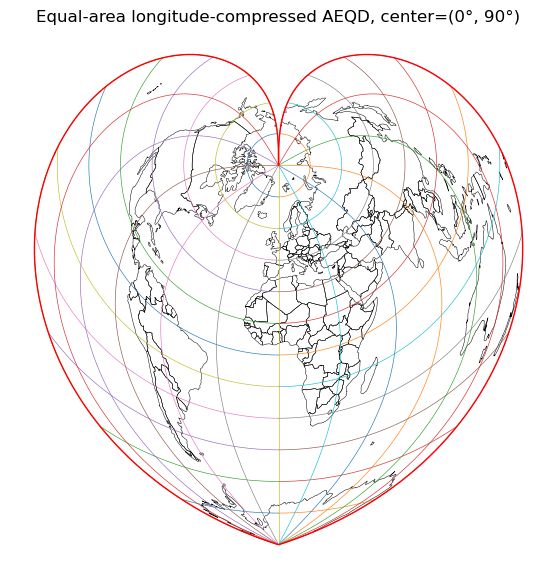

In [17]:
fig, ax = plt.subplots(figsize=(12, 7))

for geom in world.geometry:
    plot_geom_general(ax, geom)

# parallels
for lat in range(-75, 76, 15):
    for lo, hi in [(-180, 0), (0, 180)]:
        lons = np.linspace(lo, hi, 361)
        lats = np.full_like(lons, lat)
        x, y = project_array_general(lons, lats, lon0_deg, lat0_deg)
        ax.plot(x, y, linewidth=0.45)

# meridians
for lon in range(-180, 181, 30):
    lats = np.linspace(-89.9, 89.9, 721)
    lons = np.full_like(lats, lon)
    x, y = project_array_general(lons, lats, lon0_deg, lat0_deg)
    ax.plot(x, y, linewidth=0.45)

# map edge
for lon in [-180, 180]:
    lats = np.linspace(-89.9, 89.9, 721)
    lons = np.full_like(lats, lon)
    x, y = project_array_general(lons, lats, lon0_deg, lat0_deg)
    ax.plot(x, y, color="red", linewidth=1.0)

ax.set_aspect("equal", adjustable="box")
ax.autoscale()
ax.set_axis_off()
ax.set_title(
    f"Equal-area longitude-compressed AEQD, center=({lon0_deg}°, {lat0_deg}°)"
)

plt.show()

### Polar Case: Werner Projection

When the projection center is placed at the North Pole $(\phi_0 = 90^\degree)$, the longitude-compressed equal-area azimuthal equidistant projection becomes exactly the Werner projection.

In this case, every meridian remains equally spaced in geodesic distance from the pole, while the longitude compression required by the equal-area condition transforms the azimuthal equidistant construction into the classical Werner projection. The North Pole is represented as a point, and the opposite pole is compressed into a cusp whose total convergence angle is

$
2\arctan(\pi)\approx 144.686^\circ.
$

Therefore, the polar member of this projection family is not a new projection but coincides with the well-known Werner projection. For this reason, we refer to this **Longitude-Based Area Equalization of the Azimuthal Equidistant Projection** as **Park–Werner Projection**.


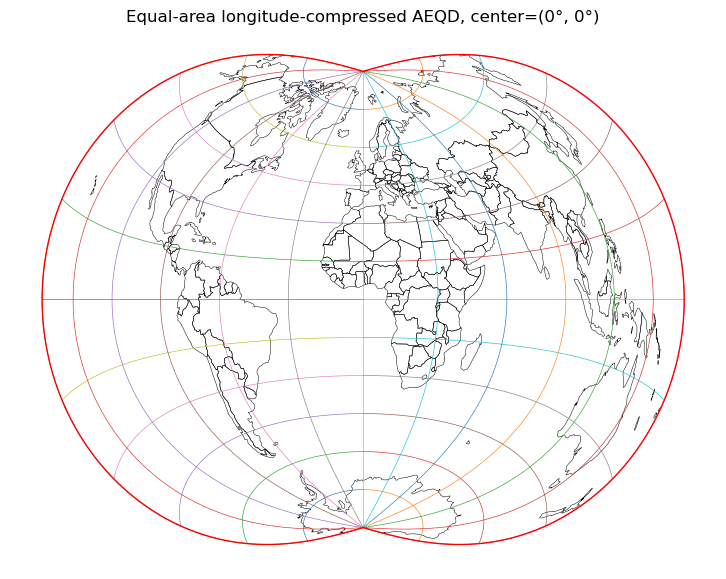

In [20]:
lat0_deg = 0
fig, ax = plt.subplots(figsize=(12, 7))

for geom in world.geometry:
    plot_geom_general(ax, geom)

# parallels
for lat in range(-75, 76, 15):
    for lo, hi in [(-180, 0), (0, 180)]:
        lons = np.linspace(lo, hi, 361)
        lats = np.full_like(lons, lat)
        x, y = project_array_general(lons, lats, lon0_deg, lat0_deg)
        ax.plot(x, y, linewidth=0.45)

# meridians
for lon in range(-180, 181, 30):
    lats = np.linspace(-89.9, 89.9, 721)
    lons = np.full_like(lats, lon)
    x, y = project_array_general(lons, lats, lon0_deg, lat0_deg)
    ax.plot(x, y, linewidth=0.45)

# map edge
for lon in [-180, 180]:
    lats = np.linspace(-89.9, 89.9, 721)
    lons = np.full_like(lats, lon)
    x, y = project_array_general(lons, lats, lon0_deg, lat0_deg)
    ax.plot(x, y, color="red", linewidth=1.0)

ax.set_aspect("equal", adjustable="box")
ax.autoscale()
ax.set_axis_off()
ax.set_title(
    f"Equal-area longitude-compressed AEQD, center=({lon0_deg}°, {lat0_deg}°)"
)

plt.show()

## Controlling Polar Convergence by the Projection Center Latitude

The generalized longitude-compressed equal-area azimuthal equidistant projection forms a continuous family of equal-area projections parameterized by the latitude of the projection center $\phi_0$.

As $\phi_0$ varies from the equator to either pole, the total convergence angle at the poles changes continuously. Consequently, one may control the shape of the projection by selecting an appropriate center latitude and thereby prescribing the convergence angle at one or both poles.

Conversely, since the relationship between the projection center latitude and the polar convergence angle is monotonic, a desired convergence angle can be specified in advance, and the corresponding value of $\phi_0$ can be determined numerically. This provides a convenient geometric parameterization of the projection family based on polar shape rather than projection-center location.

Thus, the projection may be designed either by choosing the projection center latitude directly or by prescribing the desired convergence angle at a pole and solving for the corresponding center latitude.


In [19]:
import numpy as np

def _angle_total_from_a(a, n=20001):
    """
    At a pole, tangent directions are proportional to
        (a sin λ', -cos λ')   up to a sign/reflection.
    λ' ranges from -π/a to +π/a.
    """
    if not np.isfinite(a) or a <= 0:
        return np.nan

    L = np.pi / a
    u = np.linspace(-L, L, n)

    dx = a * np.sin(u)
    dy = -np.cos(u)

    ang = np.unwrap(np.arctan2(dy, dx))
    return abs(ang[-1] - ang[0])


def pole_convergence_angles(lat0_deg):
    """
    Return total meeting angles at the north and south poles, in degrees,
    for the longitude-compressed equal-area AEQD with center latitude lat0_deg.
    """
    phi0 = np.deg2rad(lat0_deg)

    # angular distances from projection center to poles
    cN = np.pi/2 - phi0
    cS = np.pi/2 + phi0

    def a_from_c(c):
        if abs(np.sin(c)) < 1e-12:
            return np.inf
        if abs(c) < 1e-12:
            return 1.0
        return c / np.sin(c)

    aN = a_from_c(cN)
    aS = a_from_c(cS)

    AN = _angle_total_from_a(aN)
    AS = _angle_total_from_a(aS)

    return {
        "north_deg": np.rad2deg(AN),
        "south_deg": np.rad2deg(AS),
    }


def find_lat0_for_pole_angle(target_angle_deg, pole="north", tol=1e-8, max_iter=80):
    """
    Find lat0_deg such that the chosen pole has the desired total meeting angle.

    pole:
        "north" -> match north pole angle
        "south" -> match south pole angle
    """
    target = float(target_angle_deg)

    # practical attainable range is roughly [144.686..., 360]
    lo, hi = -90.0 + 1e-9, 90.0 - 1e-9

    def value(lat0):
        a = pole_convergence_angles(lat0)
        return a["north_deg"] if pole == "north" else a["south_deg"]

    # north angle increases with lat0; south angle decreases with lat0
    if pole == "north":
        v_lo, v_hi = value(lo), value(hi)
        increasing = True
    elif pole == "south":
        v_lo, v_hi = value(lo), value(hi)
        increasing = False
    else:
        raise ValueError("pole must be 'north' or 'south'")

    mn, mx = min(v_lo, v_hi), max(v_lo, v_hi)
    if not (mn <= target <= mx):
        raise ValueError(
            f"target_angle_deg={target} is outside attainable range "
            f"[{mn:.6f}, {mx:.6f}] for pole={pole}"
        )

    for _ in range(max_iter):
        mid = 0.5 * (lo + hi)
        v_mid = value(mid)

        if increasing:
            if v_mid < target:
                lo = mid
            else:
                hi = mid
        else:
            if v_mid > target:
                lo = mid
            else:
                hi = mid

        if abs(v_mid - target) < tol:
            break

    return 0.5 * (lo + hi)

In [21]:
print(pole_convergence_angles(0))
print(pole_convergence_angles(60))
print(pole_convergence_angles(90 - 1e-6))

lat0_deg = find_lat0_for_pole_angle(180, pole="north")
print(lat0_deg, pole_convergence_angles(lat0_deg))

{'north_deg': 212.48737062519496, 'south_deg': 212.48737062519496}
{'north_deg': 343.0197964308264, 'south_deg': 148.8044281039699}
{'north_deg': 360.0, 'south_deg': 144.6864256971743}
-18.603821634108243 {'north_deg': 179.99999994323468, 'south_deg': 258.211672332848}


In [39]:
lat0_deg

-18.603821634108243

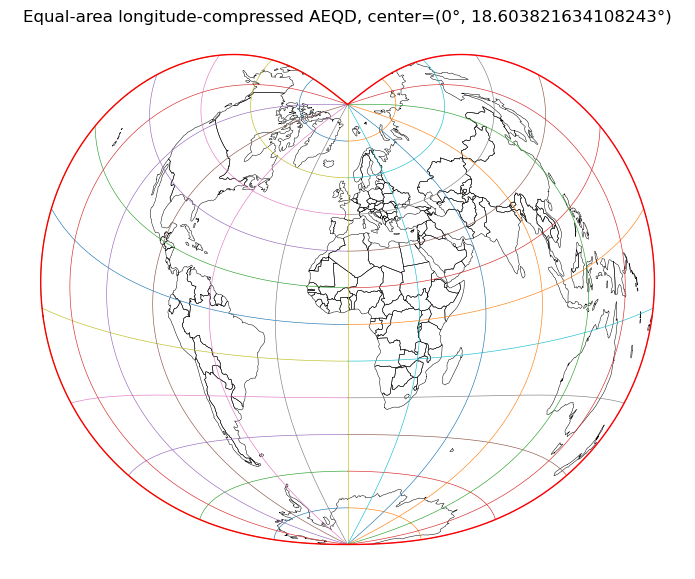

In [41]:
lat0_deg =  find_lat0_for_pole_angle(180, pole="south")
fig, ax = plt.subplots(figsize=(12, 7))

for geom in world.geometry:
    plot_geom_general(ax, geom)

# parallels
for lat in range(-75, 76, 15):
    for lo, hi in [(-180, 0), (0, 180)]:
        lons = np.linspace(lo, hi, 361)
        lats = np.full_like(lons, lat)
        x, y = project_array_general(lons, lats, lon0_deg, lat0_deg)
        ax.plot(x, y, linewidth=0.45)

# meridians
for lon in range(-180, 181, 30):
    lats = np.linspace(-89.9, 89.9, 721)
    lons = np.full_like(lats, lon)
    x, y = project_array_general(lons, lats, lon0_deg, lat0_deg)
    ax.plot(x, y, linewidth=0.45)

# map edge
for lon in [-180, 180]:
    lats = np.linspace(-89.9, 89.9, 721)
    lons = np.full_like(lats, lon)
    x, y = project_array_general(lons, lats, lon0_deg, lat0_deg)
    ax.plot(x, y, color="red", linewidth=1.0)

ax.set_aspect("equal", adjustable="box")
ax.autoscale()
ax.set_axis_off()
ax.set_title(
    f"Equal-area longitude-compressed AEQD, center=({lon0_deg}°, {lat0_deg}°)"
)

plt.show()

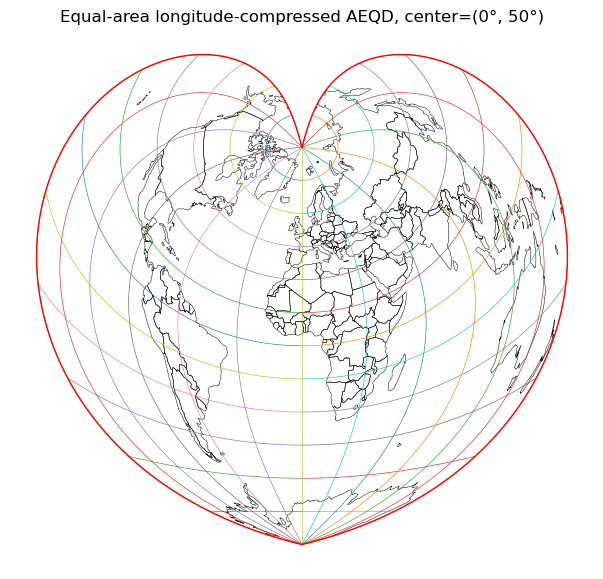

In [24]:
lat0_deg = 50
fig, ax = plt.subplots(figsize=(12, 7))

for geom in world.geometry:
    plot_geom_general(ax, geom)

# parallels
for lat in range(-75, 76, 15):
    for lo, hi in [(-180, 0), (0, 180)]:
        lons = np.linspace(lo, hi, 361)
        lats = np.full_like(lons, lat)
        x, y = project_array_general(lons, lats, lon0_deg, lat0_deg)
        ax.plot(x, y, linewidth=0.45)

# meridians
for lon in range(-180, 181, 30):
    lats = np.linspace(-89.9, 89.9, 721)
    lons = np.full_like(lats, lon)
    x, y = project_array_general(lons, lats, lon0_deg, lat0_deg)
    ax.plot(x, y, linewidth=0.45)

# map edge
for lon in [-180, 180]:
    lats = np.linspace(-89.9, 89.9, 721)
    lons = np.full_like(lats, lon)
    x, y = project_array_general(lons, lats, lon0_deg, lat0_deg)
    ax.plot(x, y, color="red", linewidth=1.0)

ax.set_aspect("equal", adjustable="box")
ax.autoscale()
ax.set_axis_off()
ax.set_title(
    f"Equal-area longitude-compressed AEQD, center=({lon0_deg}°, {lat0_deg}°)"
)

plt.show()

## Hammer-Type Extension

The same idea can be extended in a manner analogous to the Hammer and Aitoff projections. Instead of applying the equal-area longitude compression directly to the sphere, one may first compress longitudes by a constant factor, apply the generalized longitude-compressed equal-area azimuthal equidistant construction, and then expand the resulting map horizontally by the same factor.

This procedure generates a new family of projections whose outer boundary is generally wider and rounder than that of the original projection. The approach is conceptually similar to the constructions used in the Hammer and Aitoff projections, where an azimuthal projection is modified through longitude compression and subsequent horizontal stretching.

In the polar case $(\phi_0 = 90^\degree)$, this construction is equivalent to the Bottomley projection. Thus, the Bottomley projection may be interpreted as a Hammer-type modification of the polar member of the present projection family.

When the projection center lies on the equator $(\phi_0 = 0^\degree)$ and the horizontal expansion is chosen so that the final map spans exactly $180^\degree)$ from the central meridian to either edge, the resulting projection exhibits an appearance intermediate between the Hammer and Aitoff projections. However, its outline is generally smoother and more rounded, reflecting the geometry inherited from the longitude-compressed equal-area azimuthal equidistant construction.

This Hammer-type modification therefore provides an additional degree of freedom, allowing the projection's overall aspect ratio and boundary shape to be adjusted while preserving the fundamental geometric structure of the underlying projection family.


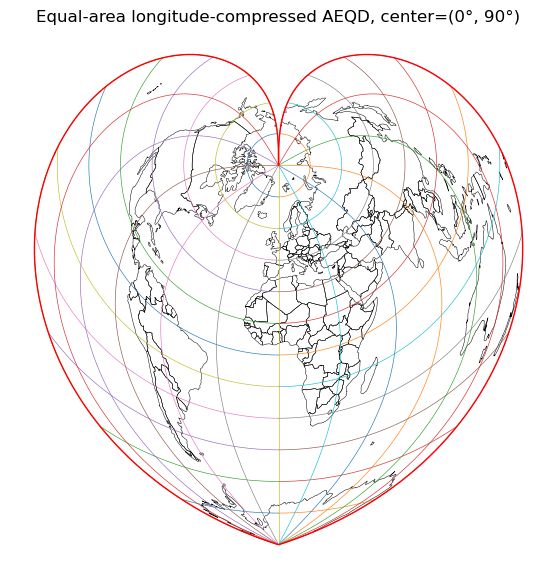

In [26]:
lat0_deg = 90
fig, ax = plt.subplots(figsize=(12, 7))

for geom in world.geometry:
    plot_geom_general(ax, geom)

# parallels
for lat in range(-75, 76, 15):
    for lo, hi in [(-180, 0), (0, 180)]:
        lons = np.linspace(lo, hi, 361)
        lats = np.full_like(lons, lat)
        x, y = project_array_general(lons, lats, lon0_deg, lat0_deg)
        ax.plot(x, y, linewidth=0.45)

# meridians
for lon in range(-180, 181, 30):
    lats = np.linspace(-89.9, 89.9, 721)
    lons = np.full_like(lats, lon)
    x, y = project_array_general(lons, lats, lon0_deg, lat0_deg)
    ax.plot(x, y, linewidth=0.45)

# map edge
for lon in [-180, 180]:
    lats = np.linspace(-89.9, 89.9, 721)
    lons = np.full_like(lats, lon)
    x, y = project_array_general(lons, lats, lon0_deg, lat0_deg)
    ax.plot(x, y, color="red", linewidth=1.0)

ax.set_aspect("equal", adjustable="box")
ax.autoscale()
ax.set_axis_off()
ax.set_title(
    f"Equal-area longitude-compressed AEQD, center=({lon0_deg}°, {lat0_deg}°)"
)

plt.show()

In [38]:
def project_array_general_flatpole(lon, lat, lon0_deg=0, lat0_deg=0, flat=1):
    lon = np.asarray(lon)/flat
    lat = np.asarray(lat)

    x = np.empty_like(lon, dtype=float)
    y = np.empty_like(lat, dtype=float)

    for i in range(len(lon)):
        x[i], y[i] = project_point_general(
            lon[i], lat[i],
            lon0_deg=lon0_deg,
            lat0_deg=lat0_deg
        )

    return x*flat, y

def project_ring_general_flatpole(coords, flat=1):
    coords = densify_coords(coords)

    lon = np.array([p[0] for p in coords])
    lat = np.array([p[1] for p in coords])

    x, y = project_array_general(lon/flat, lat, lon0_deg, lat0_deg)
    return np.column_stack([x*flat, y])


def plot_geom_general_flatpole(ax, geom, flat=1):
    if geom.is_empty:
        return

    if isinstance(geom, Polygon):
        xy = project_ring_general_flatpole(geom.exterior.coords, flat)
        plot_polyline_with_nan(ax, xy, color="black", linewidth=0.35)

    elif isinstance(geom, MultiPolygon):
        for g in geom.geoms:
            plot_geom_general_flatpole(ax, g, flat)

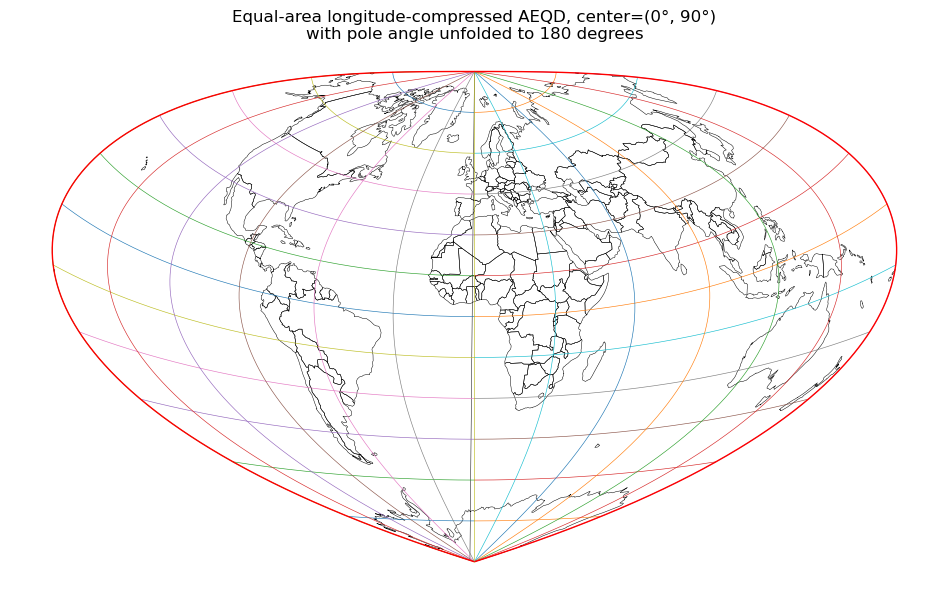

In [42]:
lat0_deg = 90
fig, ax = plt.subplots(figsize=(12, 7))
flat=2
for geom in world.geometry:
    plot_geom_general_flatpole(ax, geom, flat)

# parallels
for lat in range(-75, 76, 15):
    for lo, hi in [(-180, 0), (0, 180)]:
        lons = np.linspace(lo, hi, 361)
        lats = np.full_like(lons, lat)
        x, y = project_array_general(lons/flat, lats, lon0_deg, lat0_deg)
        ax.plot(x*flat, y, linewidth=0.45)

# meridians
for lon in range(-180, 181, 30):
    lats = np.linspace(-89.9, 89.9, 721)
    lons = np.full_like(lats, lon)
    x, y = project_array_general(lons/flat, lats, lon0_deg, lat0_deg)
    ax.plot(x*flat, y, linewidth=0.45)

# map edge
for lon in [-180, 180]:
    lats = np.linspace(-89.9, 89.9, 721)
    lons = np.full_like(lats, lon)
    x, y = project_array_general(lons/flat, lats, lon0_deg, lat0_deg)
    ax.plot(x*flat, y, color="red", linewidth=1.0)

ax.set_aspect("equal", adjustable="box")
ax.autoscale()
ax.set_axis_off()
ax.set_title(
    f"Equal-area longitude-compressed AEQD, center=({lon0_deg}°, {lat0_deg}°)\n"
    f"with pole angle unfolded to 180 degrees"
)

plt.show()

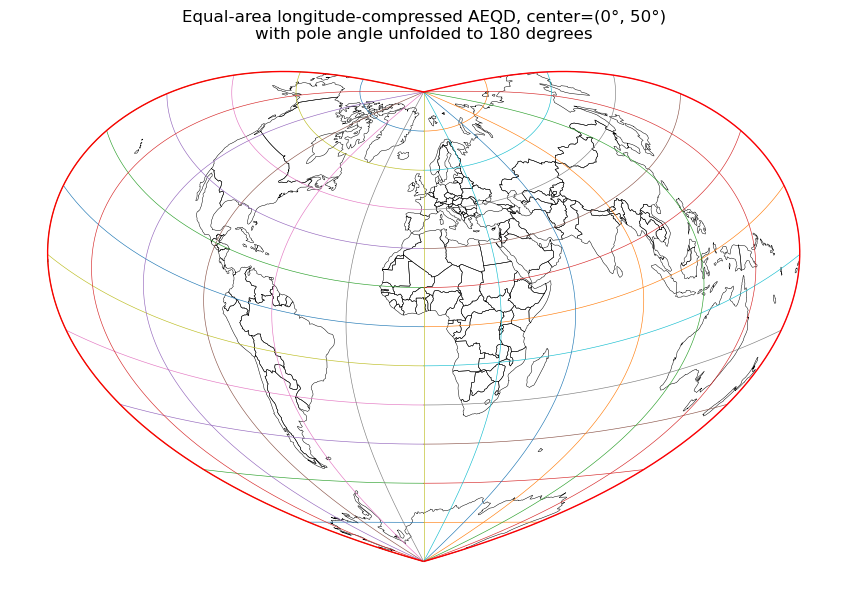

In [44]:
lat0_deg = 50
fig, ax = plt.subplots(figsize=(12, 7))
flat=1.5
for geom in world.geometry:
    plot_geom_general_flatpole(ax, geom, flat)

# parallels
for lat in range(-75, 76, 15):
    for lo, hi in [(-180, 0), (0, 180)]:
        lons = np.linspace(lo, hi, 361)
        lats = np.full_like(lons, lat)
        x, y = project_array_general(lons/flat, lats, lon0_deg, lat0_deg)
        ax.plot(x*flat, y, linewidth=0.45)

# meridians
for lon in range(-180, 181, 30):
    lats = np.linspace(-89.9, 89.9, 721)
    lons = np.full_like(lats, lon)
    x, y = project_array_general(lons/flat, lats, lon0_deg, lat0_deg)
    ax.plot(x*flat, y, linewidth=0.45)

# map edge
for lon in [-180, 180]:
    lats = np.linspace(-89.9, 89.9, 721)
    lons = np.full_like(lats, lon)
    x, y = project_array_general(lons/flat, lats, lon0_deg, lat0_deg)
    ax.plot(x*flat, y, color="red", linewidth=1.0)

ax.set_aspect("equal", adjustable="box")
ax.autoscale()
ax.set_axis_off()
ax.set_title(
    f"Equal-area longitude-compressed AEQD, center=({lon0_deg}°, {lat0_deg}°)\n"
    f"with pole angle unfolded"
)

plt.show()

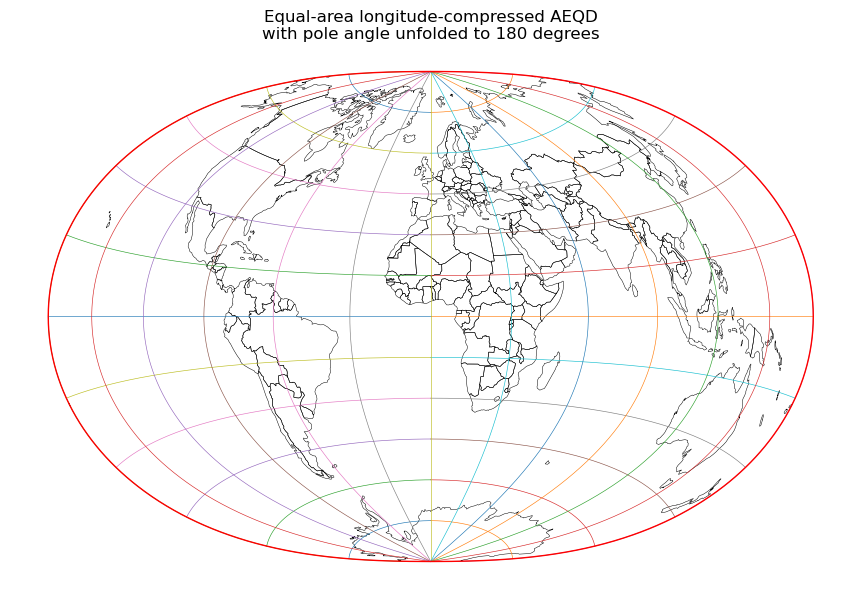

In [46]:
lat0_deg = 0
fig, ax = plt.subplots(figsize=(12, 7))
flat=4.0 / np.pi
for geom in world.geometry:
    plot_geom_general_flatpole(ax, geom, flat)

# parallels
for lat in range(-75, 76, 15):
    for lo, hi in [(-180, 0), (0, 180)]:
        lons = np.linspace(lo, hi, 361)
        lats = np.full_like(lons, lat)
        x, y = project_array_general(lons/flat, lats, lon0_deg, lat0_deg)
        ax.plot(x*flat, y, linewidth=0.45)

# meridians
for lon in range(-180, 181, 30):
    lats = np.linspace(-89.9, 89.9, 721)
    lons = np.full_like(lats, lon)
    x, y = project_array_general(lons/flat, lats, lon0_deg, lat0_deg)
    ax.plot(x*flat, y, linewidth=0.45)

# map edge
for lon in [-180, 180]:
    lats = np.linspace(-89.9, 89.9, 721)
    lons = np.full_like(lats, lon)
    x, y = project_array_general(lons/flat, lats, lon0_deg, lat0_deg)
    ax.plot(x*flat, y, color="red", linewidth=1.0)

ax.set_aspect("equal", adjustable="box")
ax.autoscale()
ax.set_axis_off()
ax.set_title(
    "Equal-area longitude-compressed AEQD\n"
    "with pole angle unfolded to 180 degrees"
)

plt.show()

## Conclusion

By varying the projection center latitude and the horizontal flattening factor, a continuous family of equal-area projections can be obtained, ranging from the classical Werner or Bottomley projections to a variety of previously unexplored forms.

We hope that this framework may serve as a useful tool for designing new equal-area world maps with desired geometric and aesthetic properties.